# Laboratorio 1 - Preparación de un corpus y EDA

Notebook paso a paso, con celdas de explicación y comentarios en el código.

**Corpus:** Spanish News Classification  

## 1. Objetivo

Explorar el corpus, aplicar el pipeline de normalización visto en clase y responder las preguntas de EDA y análisis.

En esta parte se cargan las librerías que usaremos en todo el notebook:

- `pandas` para manipular la tabla del corpus.
- `re` para tokenización con expresiones regulares.
- `nltk` para el stemmer de español como respaldo.
- `matplotlib` para gráficas.
- `wordcloud` para la nube de palabras.
- `spaCy` para intentar la lematización real en español.

In [1]:
# Importaciones
from collections import Counter
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from wordcloud import WordCloud

# Descargar recursos de NLTK (solo la primera vez)
nltk.download("stopwords")

# Cargar modelo de español
nlp = spacy.load("es_core_news_sm")

# Stopwords en español
ES_STOPWORDS = set(nltk_stopwords.words("spanish"))

# Rutas del proyecto
INPUT = Path("df_total.csv")          # Archivo de entrada


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/michelle/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Cargar el corpus
df = pd.read_csv(INPUT)
df.head()

,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


## 2. Explorar el corpus antes de tocarlo

Aquí respondemos exactamente lo que pide el laboratorio:

- cuántos documentos tiene el corpus,
- qué columnas contiene,
- qué información guarda cada una,
- cuántas categorías hay y cómo se distribuyen,
- si hay filas vacías o duplicadas.

Esta exploración se hace **antes** de aplicar cualquier limpieza.

In [3]:
# Resumen básico del corpus
print("Documentos:", len(df))
print("Columnas:", df.columns.tolist())
print("\nVacíos por columna:\n", df.isna().sum())
print("\nFilas duplicadas:", int(df.duplicated().sum()))
print("\nDistribución de categorías:\n", df["Type"].value_counts())

Documentos: 1217
Columnas: ['url', 'news', 'Type']

Vacíos por columna:
 url     0
news    0
Type    0
dtype: int64

Filas duplicadas: 75

Distribución de categorías:
 Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64


### Respuestas de exploración

- El corpus tiene **1217 documentos**.
- Las columnas son **url**, **news** y **Type**.
- `url` identifica la fuente o enlace de la noticia.  
- `news` contiene el texto completo de la noticia.  
- `Type` guarda la categoría temática.
- Se detectaron **0 filas vacías** y **75 filas duplicadas**.
- La distribución de categorías aparece en la tabla siguiente.

In [4]:
# Distribución de categorías
category_counts = df["Type"].value_counts()
category_counts

Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64

# 3. Preparación del corpus

Ahora aplicamos el pipeline de normalización en el mismo orden del laboratorio:

1. Tokenización  
2. Minúsculas  
3. Eliminar puntuación  
4. Eliminar stopwords  
5. Lematización

Además, después de cada paso contaremos:
- **tokens**: ocurrencias totales,
- **tipos**: palabras distintas.

In [5]:
# Configuración del preprocesamiento
punct_re = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)
word_re = re.compile(r"^\w+$", flags=re.UNICODE)
stopwords = set(ES_STOPWORDS) | {"rt", "http", "https", "www", "com"}

# Tokenizar: divide cada texto en palabras y signos
def tokenize(text):
    return punct_re.findall(str(text))

# Pasar a minúsculas
def to_lower(tokens):
    return [t.lower() for t in tokens]

# Quitar puntuación
def remove_punct(tokens):
    return [t for t in tokens if word_re.match(t)]

# Quitar stopwords
def remove_stop(tokens):
    return [t for t in tokens if t not in stopwords]

# Lematizar con spaCy
def lemmatize_tokens(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc if token.lemma_ != "-PRON-"]

# Normalización final
def normalize_tokens(text):
    tokens = tokenize(text)
    tokens = to_lower(tokens)
    tokens = remove_punct(tokens)
    tokens = remove_stop(tokens)
    tokens = lemmatize_tokens(tokens)
    return tokens

In [6]:
# Medir tokens y tipos después de cada paso
def flatten(series):
    return [t for doc in series for t in doc]

stage_tokens = {
    "Tokenización": flatten(df["news"].apply(tokenize)),
    "Minúsculas": flatten(df["news"].apply(lambda x: to_lower(tokenize(x)))),
    "Eliminar puntuación": flatten(df["news"].apply(lambda x: remove_punct(to_lower(tokenize(x))))),
    "Eliminar stopwords": flatten(df["news"].apply(lambda x: remove_stop(remove_punct(to_lower(tokenize(x)))))),
    "Lematización": flatten(df["news"].apply(normalize_tokens)),
}

stage_summary = pd.DataFrame([
    {"Paso": stage, "Tokens": len(tokens), "Tipos": len(set(tokens))}
    for stage, tokens in stage_tokens.items()
])

stage_summary["Reducción de vocabulario vs. tokenización (%)"] = (
    (stage_summary.loc[0, "Tipos"] - stage_summary["Tipos"]) / stage_summary.loc[0, "Tipos"] * 100
).round(2)

stage_summary

,Paso,Tokens,Tipos,Reducción de vocabulario vs. tokenización (%)
0,Tokenización,684297,32606,0.00
1,Minúsculas,684297,29571,9.31
2,Eliminar puntuación,637564,29530,9.43
3,Eliminar stopwords,339170,29315,10.09
4,Lematización,339206,22398,31.31


## 4. ¿Qué es un EDA?

**EDA** significa *Exploratory Data Analysis* o **Análisis Exploratorio de Datos**.

Su objetivo es:
- entender la estructura del conjunto de datos,
- detectar errores, vacíos, duplicados y valores raros,
- identificar patrones, tendencias y distribuciones,
- decidir cómo limpiar, transformar o modelar los datos después.

En este laboratorio, el EDA nos ayuda a entender cómo se comporta el corpus antes de entrenar un modelo o hacer un análisis más profundo.

In [7]:
# Aplicar la normalización completa al corpus
df["tokens"] = df["news"].apply(normalize_tokens)
df["token_count"] = df["tokens"].str.len()
df.head()

,url,news,Type,tokens,token_count
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra,"[foro, banca, articulador, empresarial, desarr...",110
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones,"[regulador, valor, chino, decir, domingo, busc...",186
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas,"[industria, históricamente, masculino, aviació...",201
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia,"[dato, marzo, ipc, interanual, encadenar, deci...",259
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra,"[ayer, cartagena, dar, inicio, versión, número...",420


In [8]:
# Estadísticas globales
all_norm_tokens = flatten(df["tokens"])
freq = Counter(all_norm_tokens)
global_tokens = len(all_norm_tokens)
global_types = len(set(all_norm_tokens))
global_ttr = global_types / global_tokens
reduction_total = (len(set(stage_tokens["Tokenización"])) - global_types) / len(set(stage_tokens["Tokenización"])) * 100

pd.DataFrame([
    ["Tokens totales normalizados", global_tokens],
    ["Tipos totales normalizados", global_types],
    ["Riqueza léxica global (type/token)", round(global_ttr, 4)],
    ["Reducción total del vocabulario (%)", round(reduction_total, 2)],
], columns=["Métrica", "Valor"])

,Métrica,Valor
0,Tokens totales normalizados,339206.000
1,Tipos totales normalizados,22398.000
2,Riqueza léxica global (type/token),0.066
3,Reducción total del vocabulario (%),31.310


In [9]:
# Tabla de frecuencias: 20 palabras más frecuentes
top20 = pd.DataFrame(freq.most_common(20), columns=["Palabra", "Frecuencia"])
top20

,Palabra,Frecuencia
0,poder,2531
1,bbva,2527
2,año,2240
3,banco,1561
4,país,1524
5,empresa,1410
6,inflación,1404
7,nuevo,1292
8,hacer,1257
9,precio,1247


In [10]:
# Riqueza léxica por categoría
cat_rows = []
for cat, g in df.groupby("Type"):
    toks = flatten(g["tokens"])
    cat_rows.append({
        "Categoria": cat,
        "Tokens": len(toks),
        "Tipos": len(set(toks)),
        "type_token_ratio": len(set(toks)) / len(toks),
    })
category_richness = pd.DataFrame(cat_rows).sort_values("type_token_ratio", ascending=False)
category_richness

,Categoria,Tokens,Tipos,type_token_ratio
5,Reputacion,7815,2537,0.324632
4,Regulaciones,37783,7026,0.185957
0,Alianzas,49927,8666,0.173573
3,Otra,29092,4974,0.170975
6,Sostenibilidad,57540,8052,0.139937
1,Innovacion,61183,6871,0.112302
2,Macroeconomia,95866,9421,0.098273


**Riqueza léxica por categoría.**  
La categoría `Reputacion` presenta la mayor riqueza léxica relativa (**0.3246**) porque tiene pocos documentos y un vocabulario más variado en proporción. En cambio, `Macroeconomia` muestra la menor riqueza léxica relativa (**0.0983**), lo cual es coherente con una categoría grande y temática más repetitiva. Esto sugiere que las categorías más amplias tienden a repetir más vocabulario especializado.

## VISUALIZACION 

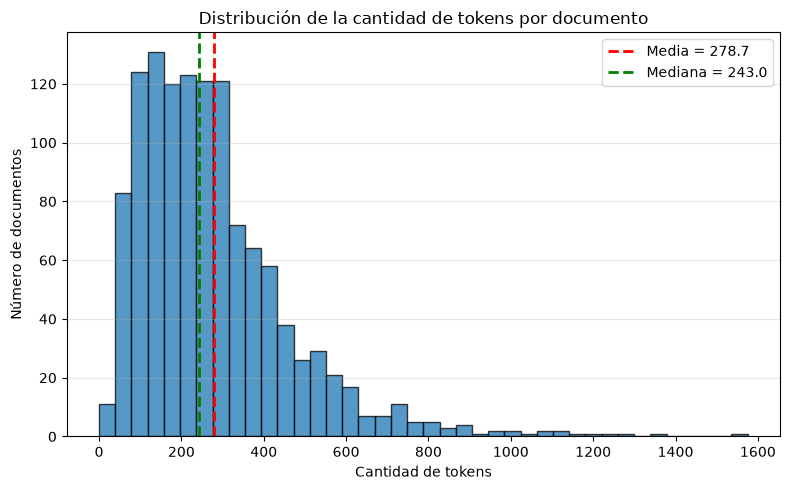

In [11]:
# Histograma de la cantidad de tokens por documento

media = df["token_count"].mean()
mediana = df["token_count"].median()

plt.figure(figsize=(8,5))

plt.hist(
    df["token_count"],
    bins="auto",
    edgecolor="black",
    alpha=0.75
)

plt.axvline(media,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Media = {media:.1f}")

plt.axvline(mediana,
            color="green",
            linestyle="--",
            linewidth=2,
            label=f"Mediana = {mediana:.1f}")

plt.title("Distribución de la cantidad de tokens por documento")
plt.xlabel("Cantidad de tokens")
plt.ylabel("Número de documentos")
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


/var/folders/c2/7hv2k_zd35380q4h8tgsvc3h0000gn/T/ipykernel_57179/1749766272.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["token_count"], vert=False)


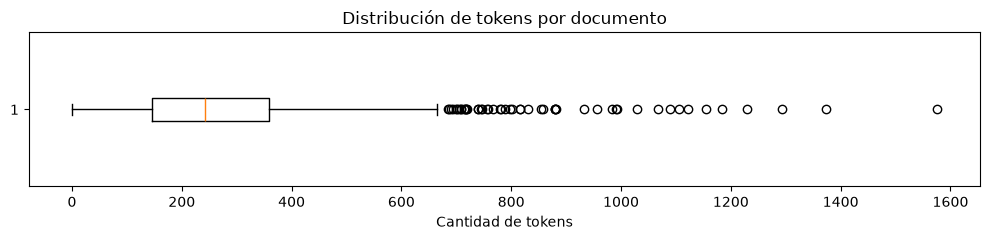

In [12]:
plt.figure(figsize=(10,2.5))

plt.boxplot(df["token_count"], vert=False)

plt.title("Distribución de tokens por documento")
plt.xlabel("Cantidad de tokens")

plt.tight_layout()
plt.show()

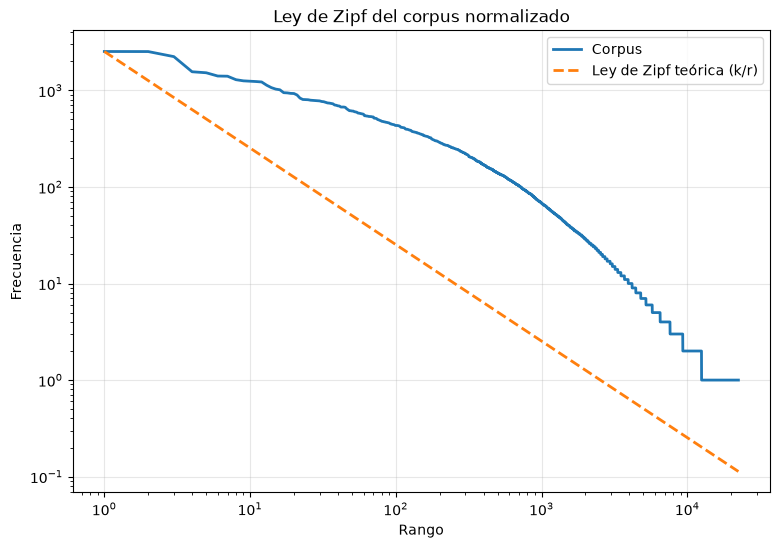

Pendiente aproximada: -1.374


In [13]:

# Ley de Zipf

freq_sorted = np.array(sorted(freq.values(), reverse=True))
ranks = np.arange(1, len(freq_sorted) + 1)

# Pendiente aproximada
zipf_slope, zipf_intercept = np.polyfit(np.log10(ranks), np.log10(freq_sorted), 1)

# Curva teórica
zipf_theoretical = freq_sorted[0] / ranks

plt.figure(figsize=(9,6))

plt.plot(ranks, freq_sorted,
         label="Corpus",
         linewidth=2)

plt.plot(ranks, zipf_theoretical,
         "--",
         label="Ley de Zipf teórica (k/r)",
         linewidth=2)

plt.xscale("log")
plt.yscale("log")

plt.title("Ley de Zipf del corpus normalizado")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

print(f"Pendiente aproximada: {zipf_slope:.3f}")


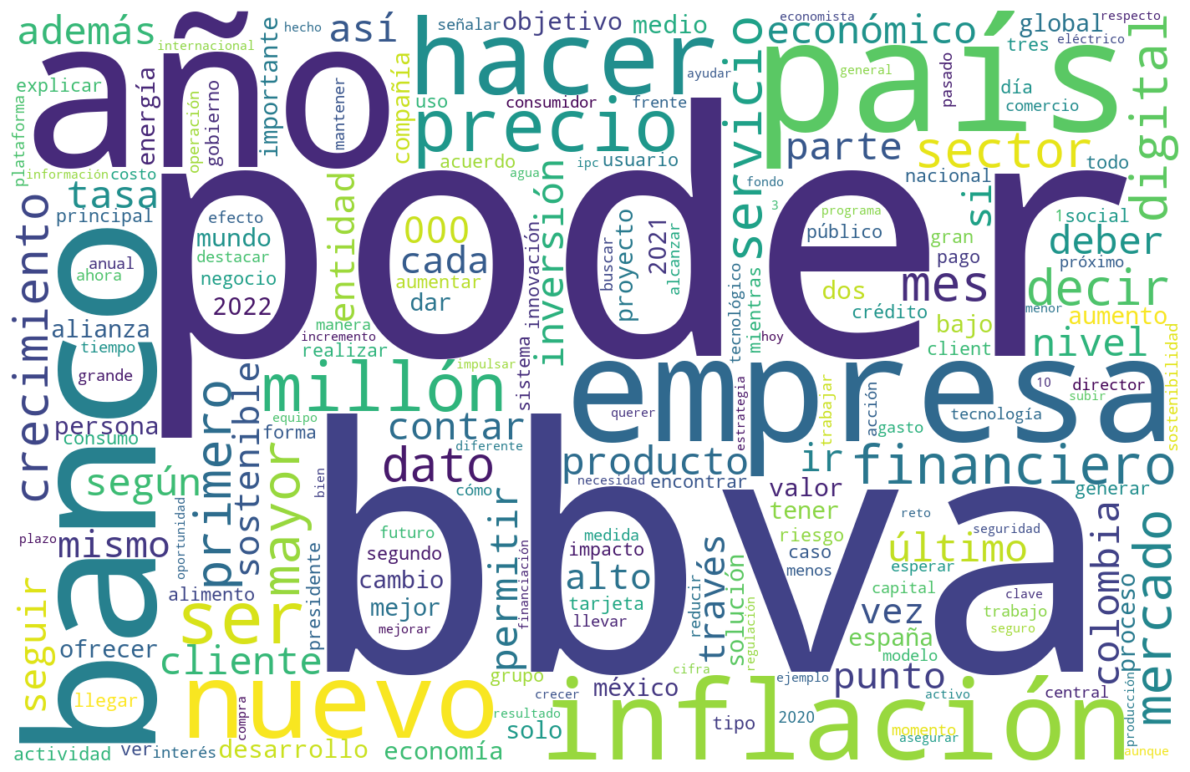

In [14]:


# Nube de palabras

wc = WordCloud(width=1400, height=900, background_color="white").generate_from_frequencies(freq)

plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()


In [15]:

# Comparación por categoría
# Se comparan las 10 palabras más frecuentes de dos categorías


def top_words_by_category(category, n=10):
    """
    Devuelve las n palabras más frecuentes de una categoría.
    
    Parámetros:
        category (str): Nombre de la categoría.
        n (int): Número de palabras a mostrar.
    
    Retorna:
        DataFrame con las palabras y su frecuencia.
    """
    
    # Obtener todos los tokens de la categoría seleccionada
    tokens_categoria = flatten(df.loc[df["Type"] == category, "tokens"])

    # Contar la frecuencia de cada palabra
    frecuencia = Counter(tokens_categoria)

    # Crear el DataFrame con las n palabras más frecuentes
    return pd.DataFrame(
        frecuencia.most_common(n),
        columns=["Palabra", "Frecuencia"]
    )


# Categorías a comparar
categorias = ["Innovacion", "Macroeconomia","Sostenibilidad","Alianzas"]

# Mostrar el Top 10 de cada categoría
for categoria in categorias:
    print(f"\nTop 10 palabras más frecuentes - {categoria}")
    display(top_words_by_category(categoria))


Top 10 palabras más frecuentes - Innovacion


,Palabra,Frecuencia
0,bbva,1120
1,poder,588
2,banco,415
3,cliente,398
4,digital,387
5,nuevo,370
6,empresa,362
7,dato,352
8,permitir,314
9,financiero,309



Top 10 palabras más frecuentes - Macroeconomia


,Palabra,Frecuencia
0,inflación,1331
1,precio,1016
2,año,1003
3,poder,679
4,bbva,547
5,mes,530
6,mayor,523
7,tasa,516
8,país,456
9,aumento,421



Top 10 palabras más frecuentes - Sostenibilidad


,Palabra,Frecuencia
0,bbva,481
1,poder,436
2,sostenible,387
3,energía,374
4,agua,274
5,año,249
6,sostenibilidad,231
7,eléctrico,231
8,objetivo,223
9,empresa,205



Top 10 palabras más frecuentes - Alianzas


,Palabra,Frecuencia
0,alianza,427
1,país,369
2,poder,341
3,colombia,292
4,millón,274
5,año,261
6,nuevo,256
7,empresa,237
8,hacer,203
9,mercado,193


**Comparación por categoría.**  
La comparación de categorías muestra que el vocabulario cambia según el tema. En `Innovacion` aparecen palabras como `cliente`, `digital`, `financiero` y `plataforma`, mientras que en `Macroeconomia` predominan `inflación`, `precio`, `tasa`, `año` y `país`. Esto confirma que el corpus está bien organizado por temática y que el preprocesamiento conserva diferencias útiles para el análisis.

### Lectura rápida de los resultados

- La distribución de tokens por documento suele ser asimétrica: algunos documentos son mucho más largos que otros.  
- La curva de Zipf en escala log-log debería verse aproximadamente lineal y descendente.  
- En las categorías, el vocabulario cambia según el tema: por ejemplo, en `Innovacion` suelen dominar términos tecnológicos y de cliente, mientras que en `Macroeconomia` aparecen palabras de inflación, precios, tasas y crecimiento.

### 6. Análisis de resultados

**Ley de Zipf.**  
La curva obtenida en escala log-log muestra un comportamiento cercano al teórico. La pendiente aproximada fue de **-1.374**, por lo que la distribución conserva la forma descendente esperada en un corpus natural. 

La diferencia con la curva ideal se explica porque el corpus no es completamente homogéneo: está compuesto por noticias de negocios y economía, con muchas repeticiones de nombres propios, instituciones y términos muy frecuentes como `bbva`, `banco`, `inflación` o `poder`.

### Reducción del vocabulario
La normalización sí tuvo un efecto claro. El vocabulario pasó de **32,606 tipos** en la tokenización inicial a **22,398 tipos** después de la lematización, es decir, una reducción total de **31.31%** respecto al vocabulario inicial. Por pasos, la reducción del vocabulario fue aproximadamente:  
- **Minúsculas:** de 32,606 a 29,571 tipos (**9.31%**).  
- **Eliminar puntuación:** de 29,571 a 29,530 tipos (**0.14%**).  
- **Eliminar stopwords:** de 29,530 a 29,315 tipos (**0.73%**).  
- **Lematización:** de 29,315 a 22,398 tipos (**23.59%**).  

El paso con mayor impacto fue la **lematización**, porque unifica distintas formas flexionadas de una misma palabra en un solo lema.

### Efecto de eliminar stopwords
Quitar stopwords redujo bastante la cantidad total de tokens y ayudó a concentrar el análisis en palabras con más contenido semántico. 

En este corpus, esa limpieza no destruye el sentido general de las noticias porque la temática principal sigue estando marcada por sustantivos y nombres propios. 

Sin embargo, siempre hay que revisar el contexto ya que algunas palabras muy frecuentes pueden aportar mucha informacion 


----

-----

LABORATORIO 2 - REPRESENTACIONES BÁSICAS DE TEXTO

7. Preparación para el Laboratorio 2
8. Bag of Words
9. Vectores de conteo y dispersión
10. N-gramas
11. TF-IDF
12. Similitud coseno
13. Análisis de resultados del Laboratorio 2
14. Conclusiones

### Preparación para las representaciones de texto

Del Laboratorio 1 ya se dispone del corpus cargado y de una columna `tokens`
que contiene cada noticia después de aplicar tokenización, conversión a
minúsculas, eliminación de puntuación, eliminación de stopwords y
lematización.

Para este laboratorio se creó la columna `texto_normalizado`, que reconstruye
cada documento uniendo nuevamente sus tokens mediante espacios. Esta
representación será utilizada como entrada para `CountVectorizer` y
`TfidfVectorizer`.

In [16]:


# Reconstruir cada documento normalizado como texto.
# En el Laboratorio 1 cada documento quedó representado
# como una lista de tokens. Para usar CountVectorizer y
# TfidfVectorizer unimos nuevamente los tokens con espacios.

df["texto_normalizado"] = df["tokens"].apply(lambda tokens: " ".join(tokens))

# Verificar el resultado
df[["news", "texto_normalizado", "Type"]].head()

,news,texto_normalizado,Type
0,Durante el foro La banca articulador empresari...,foro banca articulador empresarial desarrollo ...,Otra
1,El regulador de valores de China dijo el domin...,regulador valor chino decir domingo buscar coo...,Regulaciones
2,En una industria históricamente masculina como...,industria históricamente masculino aviación vi...,Alianzas
3,Con el dato de marzo el IPC interanual encaden...,dato marzo ipc interanual encadenar decimoquin...,Macroeconomia
4,Ayer en Cartagena se dio inicio a la versión n...,ayer cartagena dar inicio versión número 56 co...,Otra


In [17]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [18]:

# Bag of Words (BoW)


vectorizer_bow = CountVectorizer()

X_bow = vectorizer_bow.fit_transform(df["texto_normalizado"])

vocabulario_bow = vectorizer_bow.get_feature_names_out()

print("Forma de la matriz BoW:", X_bow.shape)
print("Número de documentos:", X_bow.shape[0])
print("Tamaño del vocabulario:", X_bow.shape[1])

Forma de la matriz BoW: (1217, 21911)
Número de documentos: 1217
Tamaño del vocabulario: 21911


In [19]:
# Mostrar información básica de la representación Bag of Words

print(f"Número de documentos: {X_bow.shape[0]}")
print(f"Tamaño del vocabulario: {X_bow.shape[1]}")
print(f"Forma de la matriz BoW: {X_bow.shape}")

# Mostrar algunas palabras del vocabulario
print("\nPrimeras 20 palabras del vocabulario:")
print(vocabulario_bow[:20])

Número de documentos: 1217
Tamaño del vocabulario: 21911
Forma de la matriz BoW: (1217, 21911)

Primeras 20 palabras del vocabulario:
['00' '000' '000a' '000mentre' '001' '002' '003' '004' '005' '0052020smv'
 '006' '007' '00750' '008' '0089' '009' '00audio' '01' '010' '0100']


### Interpretación de Bag of Words

La representación Bag of Words transforma cada documento en un vector de
conteos. Cada columna representa una palabra del vocabulario y cada fila
representa un documento del corpus. El valor almacenado en una celda indica
cuántas veces aparece esa palabra en ese documento.

La principal ventaja de esta representación es que convierte el texto en
información numérica que puede ser utilizada por algoritmos de aprendizaje
automático. Además, permite identificar fácilmente qué palabras aparecen y
con qué frecuencia.

Sin embargo, Bag of Words pierde información importante del lenguaje. No
conserva el orden de las palabras, la estructura gramatical ni el contexto.
Por ejemplo, dos documentos que contienen las mismas palabras con un orden
diferente pueden obtener representaciones muy similares aunque su significado
no sea exactamente el mismo.

A cambio de esta pérdida de información, se obtiene una representación simple,
eficiente y fácil de utilizar para tareas como clasificación de documentos.

---

In [20]:

# 9. Vectores de conteo y dispersión


# Número total de celdas de la matriz
total_celdas = X_bow.shape[0] * X_bow.shape[1]

# X_bow.nnz indica cuántas celdas tienen un valor distinto de cero
celdas_no_cero = X_bow.nnz

# Las demás celdas contienen cero
celdas_cero = total_celdas - celdas_no_cero

# Porcentaje de dispersión (sparsity)
sparsity = (celdas_cero / total_celdas) * 100

print(f"Total de celdas: {total_celdas:,}")
print(f"Celdas distintas de cero: {celdas_no_cero:,}")
print(f"Celdas iguales a cero: {celdas_cero:,}")
print(f"Dispersión de la matriz: {sparsity:.2f}%")

Total de celdas: 26,665,687
Celdas distintas de cero: 228,291
Celdas iguales a cero: 26,437,396
Dispersión de la matriz: 99.14%


In [21]:

# Dispersión con diferentes tamaños de vocabulario


# Tamaños de vocabulario solicitados en el laboratorio
vocab_sizes = [100, 500, 1000, 5000]

resultados_sparsity = []

for vocab_size in vocab_sizes:

    # Crear Bag of Words limitado a las palabras
    # más frecuentes del corpus
    vectorizer = CountVectorizer(max_features=vocab_size)

    X_temp = vectorizer.fit_transform(df["texto_normalizado"])

    # Número total de celdas
    total = X_temp.shape[0] * X_temp.shape[1]

    # Número de celdas distintas de cero
    no_cero = X_temp.nnz

    # Calcular porcentaje de ceros
    sparsity_temp = ((total - no_cero) / total) * 100

    resultados_sparsity.append({
        "Vocabulario": X_temp.shape[1],
        "Dispersión (%)": sparsity_temp
    })


# Convertir resultados en DataFrame
df_sparsity = pd.DataFrame(resultados_sparsity)

df_sparsity

,Vocabulario,Dispersión (%)
0,100,69.829910
1,500,83.830567
2,1000,89.029417
3,5000,96.728710


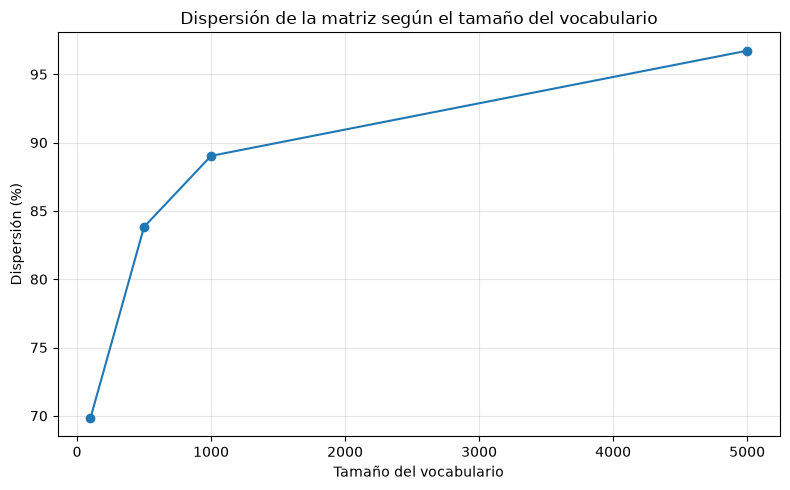

In [22]:
# Gráfica de dispersión según el tamaño del vocabulario

plt.figure(figsize=(8,5))

plt.plot(
    df_sparsity["Vocabulario"],
    df_sparsity["Dispersión (%)"],
    marker="o"
)

plt.title("Dispersión de la matriz según el tamaño del vocabulario")
plt.xlabel("Tamaño del vocabulario")
plt.ylabel("Dispersión (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de la dispersión

Los resultados muestran que la dispersión aumenta conforme se incrementa el tamaño del vocabulario. Con un vocabulario limitado a 100 palabras, el 69.83% de las celdas de la matriz son cero. Al aumentar a 500 palabras, la dispersión sube a 83.83%; con 1,000 palabras alcanza 89.03%, y con 5,000 palabras llega a 96.73%. Al utilizar el vocabulario completo, la matriz presenta una dispersión de 99.14%.

Esto ocurre porque cada documento utiliza solamente una pequeña parte del vocabulario total. Las palabras más frecuentes tienden a aparecer en muchos documentos, por lo que una matriz limitada a 100 términos contiene proporcionalmente más valores distintos de cero. Sin embargo, al incorporar miles de términos menos frecuentes, se agregan muchas columnas correspondientes a palabras que aparecen solamente en algunos documentos, aumentando así la cantidad de ceros.

Una mayor dispersión también tiene implicaciones de almacenamiento y cómputo. Si la matriz se almacenara de forma densa, sería necesario reservar memoria para millones de valores iguales a cero. Por esta razón, las representaciones de texto suelen utilizar estructuras de matrices dispersas que almacenan principalmente los valores distintos de cero.

In [24]:
# Verificar el tipo de matriz generado por CountVectorizer

print("Tipo de matriz:", type(X_bow))
print("Formato:", X_bow.getformat())

Tipo de matriz: <class 'scipy.sparse._csr.csr_matrix'>
Formato: csr


### Matrices dispersas (Sparse Matrices)

Una matriz dispersa es una matriz en la que la mayoría de sus elementos son cero. Este tipo de matriz aparece frecuentemente en NLP porque cada documento contiene solamente una pequeña parte de todas las palabras disponibles en el vocabulario.

Almacenar estas matrices como matrices densas sería poco eficiente, ya que se utilizaría memoria para guardar una gran cantidad de ceros. Por esta razón se utilizan estructuras especializadas para matrices dispersas.

Una de ellas es **CSR (Compressed Sparse Row)**. Este formato almacena principalmente los valores distintos de cero junto con información que permite identificar su posición dentro de la matriz. De esta manera se reduce considerablemente el uso de memoria y se pueden realizar operaciones matemáticas de manera más eficiente.

`CountVectorizer` de scikit-learn devuelve precisamente una matriz dispersa, lo cual resulta conveniente para representaciones Bag of Words con vocabularios grandes.

---

## 10. N-gramas

Un n-grama es una secuencia de `n` elementos consecutivos de un texto. En este apartado se comparan dos representaciones:

- **Unigramas (n=1):** cada característica corresponde a una palabra individual.
- **Bigramas (n=2):** cada característica corresponde a una secuencia de dos palabras consecutivas.

Los bigramas permiten conservar parte del orden local de las palabras, por lo que pueden representar expresiones que un modelo basado únicamente en palabras individuales no captura.

In [25]:

# 10. N-gramas: unigramas y bigramas


# Representación con unigramas
vectorizer_unigram = CountVectorizer(ngram_range=(1, 1))
X_unigram = vectorizer_unigram.fit_transform(df["texto_normalizado"])

# Representación con bigramas
vectorizer_bigram = CountVectorizer(ngram_range=(2, 2))
X_bigram = vectorizer_bigram.fit_transform(df["texto_normalizado"])

# Obtener los vocabularios
vocab_unigram = vectorizer_unigram.get_feature_names_out()
vocab_bigram = vectorizer_bigram.get_feature_names_out()

# Mostrar resultados
print("Número de documentos:", X_unigram.shape[0])

print("\nUNIGRAMAS")
print("Forma de la matriz:", X_unigram.shape)
print("Tamaño del vocabulario:", len(vocab_unigram))

print("\nBIGRAMAS")
print("Forma de la matriz:", X_bigram.shape)
print("Tamaño del vocabulario:", len(vocab_bigram))

Número de documentos: 1217

UNIGRAMAS
Forma de la matriz: (1217, 21911)
Tamaño del vocabulario: 21911

BIGRAMAS
Forma de la matriz: (1217, 223876)
Tamaño del vocabulario: 223876


In [26]:

# 15 bigramas más frecuentes del corpus


# Sumar la cantidad de veces que aparece cada bigrama
# en todos los documentos del corpus
frecuencias_bigramas = np.asarray(
    X_bigram.sum(axis=0)
).ravel()

# Crear DataFrame con bigramas y frecuencias
df_bigramas = pd.DataFrame({
    "Bigrama": vocab_bigram,
    "Frecuencia": frecuencias_bigramas
})

# Ordenar de mayor a menor y seleccionar los 15 más frecuentes
top15_bigramas = (
    df_bigramas
    .sort_values("Frecuencia", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top15_bigramas

,Bigrama,Frecuencia
0,banco central,224
1,bbva research,212
2,poder ser,208
3,cada vez,197
4,tasa interés,192
5,000 millón,189
6,entidad financiero,179
7,cambio climático,166
8,bbva méxico,155
9,punto básico,142


In [27]:

# Comparación de dispersión: unigramas vs. bigramas


def calcular_sparsity(matriz):
    total_celdas = matriz.shape[0] * matriz.shape[1]
    celdas_no_cero = matriz.nnz
    celdas_cero = total_celdas - celdas_no_cero

    return (celdas_cero / total_celdas) * 100


sparsity_unigram = calcular_sparsity(X_unigram)
sparsity_bigram = calcular_sparsity(X_bigram)

comparacion_ngramas = pd.DataFrame({
    "Representación": ["Unigramas", "Bigramas"],
    "Tamaño vocabulario": [
        X_unigram.shape[1],
        X_bigram.shape[1]
    ],
    "Dispersión (%)": [
        sparsity_unigram,
        sparsity_bigram
    ]
})

comparacion_ngramas

,Representación,Tamaño vocabulario,Dispersión (%)
0,Unigramas,21911,99.143877
1,Bigramas,223876,99.882660


### Análisis de unigramas y bigramas

La representación mediante unigramas produjo un vocabulario de **21,911 términos**, mientras que la representación mediante bigramas generó **223,876 combinaciones diferentes**. Esto muestra que al considerar secuencias de dos palabras el espacio de características aumenta considerablemente.

Los bigramas permiten capturar información que los unigramas no representan por sí solos. Por ejemplo, entre los bigramas más frecuentes aparecen expresiones como **"banco central"**, **"tasa interés"**, **"cambio climático"**, **"entidad financiero"**, **"precio consumidor"** y **"bbva research"**. Cada una representa un concepto más específico que sus palabras individuales. Por ejemplo, las palabras "banco" y "central" por separado tienen significados más generales, mientras que "banco central" identifica directamente una institución relacionada con política monetaria.

Esta capacidad constituye una ventaja de los bigramas frente a una Bolsa de Palabras basada únicamente en unigramas, ya que conservan parcialmente el orden local de las palabras y permiten identificar expresiones formadas por varios términos. Los trigramas pueden conservar todavía más contexto al representar secuencias de tres palabras.

Sin embargo, esta ventaja tiene un costo. El vocabulario aumentó de **21,911 unigramas a 223,876 bigramas**, por lo que la representación requiere un espacio de características mucho mayor. Además, muchas combinaciones aparecen solamente en pocos documentos, haciendo que la matriz sea más dispersa.

Esto se observa en la dispersión calculada: la matriz de unigramas presenta **99.14%** de valores iguales a cero, mientras que con bigramas la dispersión aumenta hasta **99.88%**. Por lo tanto, utilizar n-gramas permite representar más contexto, pero aumenta considerablemente la dimensionalidad y la dispersión de los datos.

También se observa que no todos los bigramas frecuentes aportan el mismo nivel de información. Expresiones como **"poder ser"**, **"cada vez"** o **"si bien"** son frecuentes, pero son menos específicas respecto al tema de una noticia. Esto indica que utilizar bigramas aumenta la cantidad de información contextual disponible, aunque puede ser necesario aplicar posteriormente técnicas de selección de características para conservar las combinaciones más relevantes.